In [147]:
%load_ext autoreload
%autoreload 2
import os 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [148]:
import torch 
import transformers 
import numpy as np 
from pathlib import Path 
from torch.utils.data import Dataset
from typing import Dict, Sequence
from dataclasses import dataclass
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt 
import pandas as pd 
import copy 
import csv 
from datetime import datetime 
import sys, importlib
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

from src.model_interp import (
    CODI,
    ModelArguments,
    DataArguments,
    TrainingArguments,
)
from src.data.data_processing import Polynomial_CODI, Polynomial 
from src.data.data_processing import TOKEN_DICT as POLYNOMIAL_TOKEN_DICT 
from src.test_helpers import DataCollatorForSupervisedDataset
from data_loading_helper import preprocess_polynomial, SupervisedDataset

In [149]:
selected_n_data_per_seq = 5000 
selected_n_layers = 3
selected_n_heads = 2
total_seqs = 4
polynomial_mod = 50 

### Paper Checkpoints: 

The checkpoint used in paper for 2-hop problem (total_seqs = 3):  latent-cot-thinking/save/transformer_tiny_polynomial/Layer3Head2_totalseq_3_mod50/transformer_tiny/ep_1000/lr_0.0003/seed_11/pytorch_model.bin or pytorch_model_paper.bin. 

The checkpoint used in paper for 3-hop problem (total_seqs = 4): latent-cot-thinking/save/transformer_tiny_polynomial/Layer3Head2_totalseq_4_mod50/transformer_tiny/ep_1000/lr_0.0003/seed_11/pytorch_model.bin or pytorch_model_paper.bin. 


In [150]:
# Parse Arguments 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
parser = transformers.HfArgumentParser((ModelArguments, DataArguments, TrainingArguments))
model_args, data_args, training_args = parser.parse_args_into_dataclasses(args=[
    "--model_name_or_path", "transformer_tiny",
    "--data_name", "polynomial",
    "--use_lora", "False", 
    "--use_prj", "True", 
    "--prj_dim", "256", 
    "--model_num_layers", f"{selected_n_layers}",
    "--model_num_heads", f"{selected_n_heads}", 
    "--print_ref_model_stats", "True", 
    "--n_data_per_seq", f"{selected_n_data_per_seq}",
    "--num_latent", "6",
    "--total_seqs", f"{total_seqs}",
    "--polynomial_mod", f"{polynomial_mod}",
    "--restore_from", f"../save/transformer_tiny_polynomial/Layer{selected_n_layers}Head{selected_n_heads}_totalseq_{total_seqs}_mod{polynomial_mod}/transformer_tiny/ep_1000/lr_0.0003/seed_11/pytorch_model.bin", 
    "--ckpt_dir", f"../save/transformer_tiny_polynomial/Layer{selected_n_layers}Head{selected_n_heads}_totalseq_{total_seqs}_mod{polynomial_mod}/transformer_tiny/ep_1000/lr_0.0003/seed_11/", 
    "--fix_attn_mask", "True"])
    
training_args.print_ref_model_stats = True # for testing purposes 
assert training_args.print_ref_model_stats == True, "print_ref_model_stats must be True"

# Data Loading 
Polynomial_Gen = Polynomial_CODI(mod=data_args.polynomial_mod, save_dir=Path(f'../data/polynomial_data/seq_{data_args.total_seqs}/num_{data_args.n_data_per_seq}/mod_{data_args.polynomial_mod}/codi'), cot=True)
poly_codi_test = Polynomial_Gen.load_data([i+1 for i in range(data_args.total_seqs)], 'test')
poly_codi_train = Polynomial_Gen.load_data([i+1 for i in range(data_args.total_seqs)], 'train')

train_dataset = SupervisedDataset(data_name=data_args.data_name, raw_data=poly_codi_train, tokenizer=None, bot=None, eot=None)
test_dataset = SupervisedDataset(data_name=data_args.data_name, raw_data=poly_codi_test, tokenizer=None, bot=None, eot=None)
data_collator = DataCollatorForSupervisedDataset(tokenizer=None, data_name=data_args.data_name)

cuda


In [151]:
test_dataloader = DataLoader(
    test_dataset,
    batch_size=int(len(test_dataset)),  # adjust as needed
    shuffle=False,  # typically False for test data, True for training
    collate_fn=data_collator,  # this is the key - use your data collator here
    num_workers=0,  # set to 0 for debugging, can increase for performance
    pin_memory=True if torch.cuda.is_available() else False
)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=int(len(train_dataset)),  # adjust as needed
    shuffle=False,  # typically False for test data, True for training
    collate_fn=data_collator,  # this is the key - use your data collator here
    num_workers=0,  # set to 0 for debugging, can increase for performance
    pin_memory=True if torch.cuda.is_available() else False
)


In [152]:
%%capture

# Model Loading 
model = CODI(model_args, training_args, lora_config=None) # we are not using LoRA for polynomial dataset 
model.eval() 

In [153]:
def recursive_to_cpu(obj):
    """
    Recursively move all tensors in nested structures to CPU.
    Handles: tensors, dicts, lists, tuples, and nested combinations.
    """
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu()
    elif isinstance(obj, dict):
        return {k: recursive_to_cpu(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [recursive_to_cpu(item) for item in obj]
    elif isinstance(obj, tuple):
        return tuple(recursive_to_cpu(item) for item in obj)
    elif hasattr(obj, '__dict__') and not isinstance(obj, type):
        # Handle custom objects (dataclasses, custom classes, etc.)
        # Exclude: functions, methods, classes, modules
        import types
        if isinstance(obj, (types.FunctionType, types.MethodType, types.ModuleType, 
                           types.BuiltinFunctionType, types.BuiltinMethodType)):
            return obj
        
        try:
            # Create a shallow copy and recursively process all attributes
            obj_copy = type(obj).__new__(type(obj))
            for key, value in obj.__dict__.items():
                setattr(obj_copy, key, recursive_to_cpu(value))
            return obj_copy
        except TypeError:
            # If __new__ fails (e.g., for some built-in types), return as-is
            return obj
    else:
        return obj  # Return as-is for non-tensor types (int, float, str, etc.)


### Generate clean and corrupted runs for Activation Patching

In [154]:
seq_len = total_seqs

model.to(device)
teacher_acc = []
student_acc = []
interp_dict = [] 
batch = next(iter(test_dataloader))
seq_step = int(len(batch['encoder_input_ids']) / data_args.total_seqs)

_batch = {k: v[(seq_len-1)*seq_step:(seq_len)*seq_step].to(device) for k, v in batch.items()}

clean_output = model.store_clean_run(_batch['encoder_input_ids'], _batch['decoder_input_ids'], _batch['encoder_attention_mask']) 
clean_output_cpu = recursive_to_cpu(clean_output) 

forward_output = model.forward(**_batch) 
forward_output_cpu = recursive_to_cpu(forward_output) 

#_batch = {k: v.to('cpu') for k, v in _batch.items()}
_batch = recursive_to_cpu(_batch) 

del clean_output 
del forward_output 
torch.cuda.empty_cache() 

model.to('cpu')
print()

stage0: accuracy of the predicted tokens: 1.0
stage0: mean of the prob of the target token: 0.9993321895599365
latent5: distill_loss=0
STUDENT: accuracy of the predicted tokens: 0.5843999981880188
STUDENT: mean of the prob of the target token: 0.576688826084137
loss=1.1523780822753906, ce_loss=1.1523780822753906, distill_loss=0.0, ce_loss_total=1.1523780822753906, distill_loss_total=0.0, ref_ce_loss=0.00041379412868991494



In [155]:
correct_index = forward_output_cpu['interp_dict']['student_correct'].bool()
all_answer = _batch['decoder_input_ids'][:, 2] 
clean_encoder_token_correct = _batch['encoder_input_ids'][correct_index] 
clean_decoder_token_correct  = _batch['decoder_input_ids'][correct_index] 
clean_answer_correct = all_answer[correct_index] 

In [156]:
token_to_corrupt = -1 #  -1 means the last token, -2 means the second last token, etc. 

# temperary change the last input token to make it incorrect 
corrupted_encoder_token_correct = copy.deepcopy(clean_encoder_token_correct)
corrupted_encoder_token_correct[:, token_to_corrupt - 1] = (clean_encoder_token_correct[:, token_to_corrupt - 1] * 2 ) % data_args.polynomial_mod  

### Activation Patching 

In [157]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib import cm
from matplotlib.colors import Normalize

def plot_activation_patching_results(results, figsize=(8, 4), cmap='RdBu_r', 
                                     vmin=None, vmax=None, center=0, 
                                     annot=True, fmt='.3f', title='', 
                                     phase_labels=None, seq_len=3, if_show_title=False,
                                     fontsize=10, save_figure=False):
    """
    Plot activation patching results as a heatmap using imshow.
    
    Args:
        results: dict with structure {phase: {component: {'difference': float, ...}}}
        figsize: tuple, figure size
        cmap: colormap (RdBu_r is good for diverging data centered at 0)
        vmin, vmax: color scale limits (if None, auto-scaled)
        center: value to center the colormap at
        annot: whether to show values in cells
        fmt: format string for annotations
    """
    # Extract phases and components
    phases = list(results.keys())
    if len(phases) == 9: 
        phases_label = phases
    else: 
        phases_label = [f'x{i}' for i in range(1, seq_len+1)] + ['BoT'] + [f'$\ell${i+1}' for i in range(6)] + ['EoT', 'ANS']
    
    # Get all unique components across all phases
    all_components = set()
    for phase_data in results.values():
        all_components.update(phase_data.keys())
    components = sorted(list(all_components))
    #components = ['blocks.0.hook_resid_pre', 'blocks.0.hook_resid_post', 'blocks.1.hook_resid_post', 'blocks.2.hook_resid_post']
    first_phase = list(results.keys())[0]
    components = list(results[first_phase].keys())
    components = components[::-1]
    
    def get_component_labels(num_layers):
        """Generate component labels dynamically based on number of layers."""
        labels = ['L1-pre']  # First layer pre-residual
        for i in range(1, num_layers + 1):
            labels.append(f'L{i}-post')
        return labels
    
    components_label = get_component_labels(selected_n_layers)
    print('debug components_label', components_label)
    components_label = components_label[::-1]
    
    # Create matrix
    matrix = np.zeros((len(components), len(phases)))
    for i, component in enumerate(components):
        for j, phase in enumerate(phases):
            if component in results[phase]:
                matrix[i, j] = results[phase][component]['lift']
            else:
                matrix[i, j] = np.nan  # Use NaN for missing values
    
    # Create DataFrame for better labeling
    df = pd.DataFrame(matrix, index=components_label, columns=phases)
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Handle centering for diverging colormap
    if vmin is None and vmax is None:
        abs_max = np.nanmax(np.abs(matrix - center))
        vmin = center - abs_max
        vmax = center + abs_max
    
    # Create the imshow plot
    im = ax.imshow(matrix , cmap=cmap, aspect='auto', 
                   vmin=vmin, vmax=vmax, 
                   interpolation='nearest',
                   origin='upper')
    
    # Add colorbar with more control
    cbar = plt.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label(f'% Acc. recovery (x{seq_len + token_to_corrupt + 1} patched)', rotation=270, labelpad=20, fontsize=fontsize+2)
    cbar.ax.tick_params(labelsize=fontsize)
    # Format colorbar tick labels as percentages
    cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x*100:.0f}%'))
    
    # You can further customize the colorbar:
    # cbar.ax.tick_params(labelsize=10)
    # cbar.set_ticks([vmin, center, vmax])
    
    # Set ticks and labels
    ax.set_xticks(np.arange(len(phases)))
    ax.set_yticks(np.arange(len(components_label)))
    ax.set_xticklabels(phases_label, fontsize=fontsize)
    ax.set_yticklabels(components_label, fontsize=fontsize)
    
    colormap = cm.get_cmap(cmap)
    norm = Normalize(vmin=vmin, vmax=vmax)
    # Add annotations if requested
    if annot:
        for i in range(len(components_label)):
            for j in range(len(phases)):
                value = matrix[i, j]
                if not np.isnan(value):
                    # Determine text color based on value for better visibility
                    #text_color = 'white' if abs(value - center) > (vmax - vmin) * 0.5 else 'black'
                    rgba = colormap(norm(value))
                    luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]      
                    text_color = 'black' if luminance > 0.5 else 'white'

                    # text = ax.text(j, i, format(value, fmt),
                    #              ha="center", va="center", color=text_color,
                    #              fontsize=10)

                    percentage_value = value * 100
                    text = ax.text(j, i, f'{percentage_value:.0f}%',
                                ha="center", va="center", color=text_color,
                                fontsize=fontsize)
                    
    
    # Add gridlines for cell separation (optional)
    ax.set_xticks(np.arange(len(phases)) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(components_label)) - 0.5, minor=True)
    ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5)
    ax.tick_params(which="minor", size=0)
    
    # Customize labels
    #ax.set_xlabel('Input Type', fontsize=fontsize + 2, )
    ax.set_ylabel('Layer (Residual Stream)', fontsize=fontsize + 2, )
    
    if if_show_title: 
    
        if title: 
            ax.set_title(title, fontsize=fontsize, fontweight='bold', pad=20)
        else: 
            ax.set_title(f'Activation Patching Analysis with seq_len = {seq_len}', fontsize=14, fontweight='bold', pad=20)
    
    # Rotate x-axis labels
    plt.setp(ax.get_xticklabels(), rotation=0)
    
    plt.tight_layout()


    if save_figure: 
        save_dir = f'figures/layers_{selected_n_layers}/heads_{selected_n_heads}/seq_{seq_len}/mod_{polynomial_mod}/patching/' 
        if not os.path.exists(save_dir): 
            os.makedirs(save_dir)
        fig.savefig(f'{save_dir}/patching_x_{seq_len+token_to_corrupt}.pdf', dpi=300, bbox_inches='tight')

    return fig, ax, df

# Define your metric (e.g., accuracy on specific position)
def metric_fn(logits, interp_dict):
    # Example: check if correct token is predicted at position 5  # your target
    chosen_answer = clean_answer_correct 
    #print('logits.shape', logits.shape) 
    pred = logits[:, 1, :].argmax(axis=-1) 
   #print('pred.shape', pred.shape) 
    return torch.mean((pred == chosen_answer.to(device)).float()).item()


<>:30: SyntaxWarning: invalid escape sequence '\e'
<>:30: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_2901960/3571741463.py:30: SyntaxWarning: invalid escape sequence '\e'
  phases_label = [f'x{i}' for i in range(1, seq_len+1)] + ['BoT'] + [f'$\ell${i+1}' for i in range(6)] + ['EoT', 'ANS']


debug components_label ['L1-pre', 'L1-post', 'L2-post', 'L3-post']


/tmp/ipykernel_2901960/3571741463.py:97: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


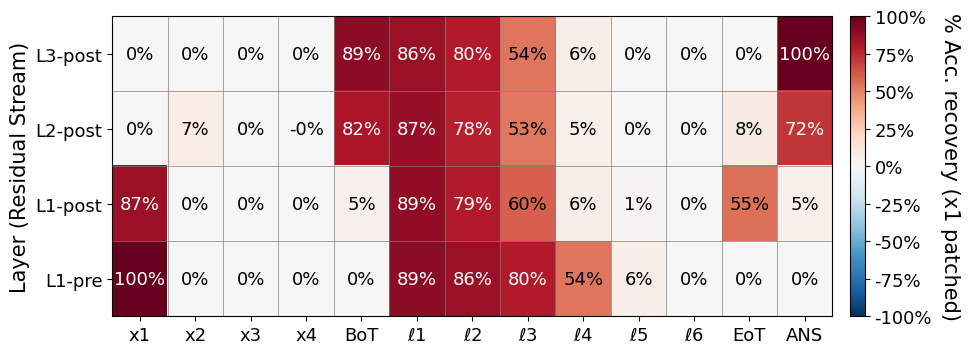

debug components_label ['L1-pre', 'L1-post', 'L2-post', 'L3-post']


/tmp/ipykernel_2901960/3571741463.py:97: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


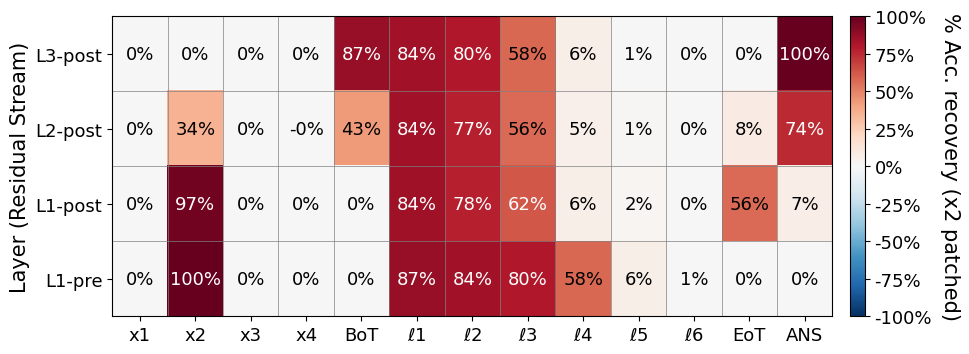

debug components_label ['L1-pre', 'L1-post', 'L2-post', 'L3-post']


/tmp/ipykernel_2901960/3571741463.py:97: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


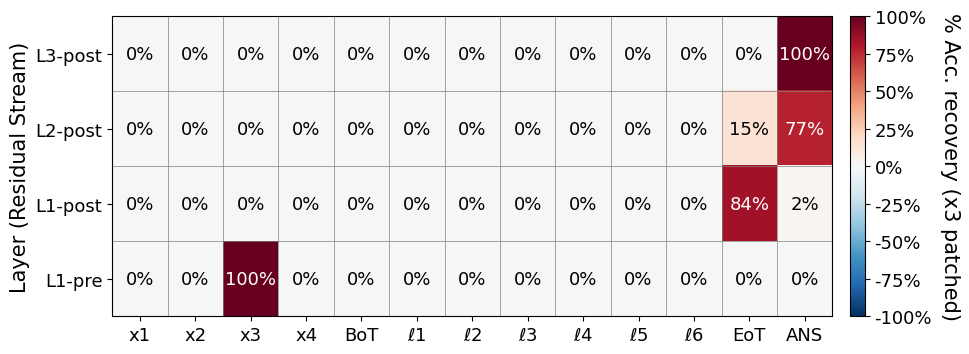

debug components_label ['L1-pre', 'L1-post', 'L2-post', 'L3-post']


/tmp/ipykernel_2901960/3571741463.py:97: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


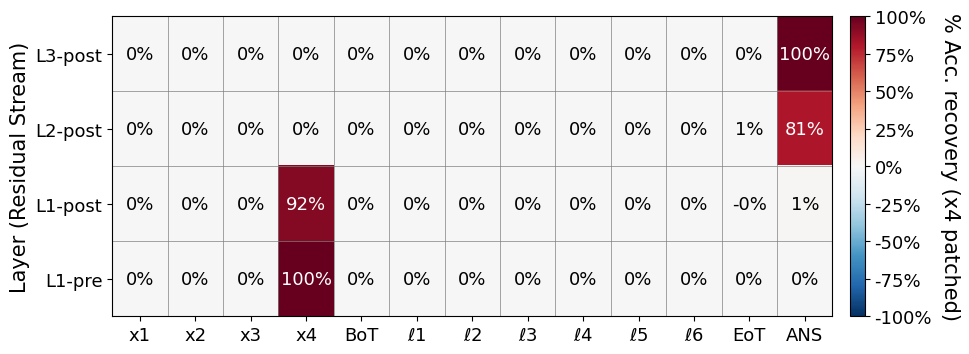

In [158]:
_save_figure = True 

for i in range(-1*seq_len, 0): 

    token_to_corrupt = i #  -1 means the last token, -2 means the second last token, etc. 

    # temperary change the last input token to make it incorrect 
    corrupted_encoder_token_correct = copy.deepcopy(clean_encoder_token_correct)
    corrupted_encoder_token_correct[:, token_to_corrupt - 1] = (clean_encoder_token_correct[:, token_to_corrupt - 1] * 2 ) % data_args.polynomial_mod  

    model.to(device)

    results = model.systematic_latent_patching(
        clean_encoder_ids=clean_encoder_token_correct.to(device),
        clean_decoder_ids=clean_decoder_token_correct.to(device),
        corrupted_encoder_ids= corrupted_encoder_token_correct.to(device), #clean_encoder_token_correct.to(device) * 2 % data_args.polynomial_mod,
        corrupted_decoder_ids=clean_decoder_token_correct.to(device), # we only corrupt the input tokens, not the [EoT, Ans] tokens
        metric_fn=metric_fn,
        encoder_attention_mask=_batch['encoder_attention_mask'][correct_index].to(device),
        input_seq_len=seq_len,
    )

    torch.cuda.empty_cache() 

    fig, ax, df = plot_activation_patching_results(results, seq_len=seq_len, figsize=(10, 3.65), fontsize=13, save_figure=_save_figure)
    plt.show()


### Logit Lens 

In [159]:
def logit_lens_analysis(model, cache, token_position=-1, num_layers=3):
    """
    Apply logit lens to intermediate layers to see what tokens 
    the model is "thinking about" at each layer.
    
    Args:
        model: Your CODI model
        clean_output_cpu: The output from model.store_clean_run() containing caches
        token_position: Which token position to analyze (-1 for last token)
    
    Returns:
        logit_lens_results: dict with logits for each layer
    """
    logit_lens_results = {}

    with torch.no_grad():
        for layer_idx in range(num_layers):
            # Get residual stream after this layer
            hook_name = f'blocks.{layer_idx}.hook_resid_post'
            residual = cache[hook_name]  # shape: [batch, seq_len, d_model]
            
            # Select the token position to analyze
            residual_at_pos = residual[:, token_position, :]  # shape: [batch, d_model]
            
            # Apply final layer normalization (TransformerLens stores this)
            normalized = model.codi.ln_final(residual_at_pos)
            
            # Apply unembedding to get logits
            logits = model.codi.unembed(normalized)  # shape: [batch, vocab_size]
            
            logit_lens_results[f'layer_{layer_idx}'] = {
                'logits': logits,
                'top_tokens': torch.topk(logits, k=10, dim=-1),  # top 10 predictions
                'probs': torch.softmax(logits, dim=-1)
            }
    
    return logit_lens_results

In [ ]:
# Add this new function after Cell 24
def extract_input_tokens(ref_input_ids, correct_index, seq_len):
    """
    Extract input tokens x1, ..., x(seq_len).
    
    Args:
        ref_input_ids: Reference input IDs tensor
        correct_index: Boolean mask for correct samples
        seq_len: Sequence length
    
    Returns:
        List of token tensors [x1, x2, ...] 
    """
    tokens = []
    for i in range(seq_len):
        # Extract token at position: 1 + i (assuming position 0 is BoT)
        token = ref_input_ids[correct_index][:, 1 + i]
        tokens.append(token)
    return tokens


# Dynamically extract tokens based on sequence length
def extract_sequence_tokens(ref_input_ids, correct_index, seq_len):
    """
    Dynamically extract s1, ..., s(seq_len) tokens.
    
    Args:
        ref_input_ids: Reference input IDs tensor
        correct_index: Boolean mask for correct samples (when using all_index, it will be all examples)
        seq_len: Sequence length (e.g., 3 or 4)
    
    Returns:
        List of token tensors [s1, s2, ...] 
    """
    tokens = []
    for i in range(seq_len-1):
        # Extract token at position: 1 + seq_len + 1 + i
        token = ref_input_ids[correct_index][:, 1 + seq_len + 1 + i]
        tokens.append(token)
    tokens.append(ref_input_ids[correct_index][:, 1 + seq_len + 1 + (seq_len-1) + 1]) # Final answer. The extra +1 is for the extra [Ans] Token. 
    return tokens


# Modified compute function for arbitrary sequence length
def compute_avg_prob_for_latent(logit_lens_results, sequence_tokens, correct_index, num_layers=3, token_prefix='s'):
    """
    Compute average probability of tokens across different layers.
    Works with arbitrary sequence length.
    
    Args:
        logit_lens_results: dict with structure {layer_idx: {'probs': tensor}}
        sequence_tokens: list of token tensors [s1, s2, ...] for each position
        correct_index: boolean mask for correct samples (when using all_index, it will be all examples)
        num_layers: number of layers to analyze
        token_prefix: prefix for the token names (e.g., 's' for s1, s2, ... 'x' for x1, x2, ...)
    
    Returns:
        dict with average probabilities for each token and overall average
    """
    seq_len = len(sequence_tokens)
    
    # Initialize results dict dynamically
    results = {
        f'{token_prefix}{i}': {'probs_by_layer': [], 'avg_prob': 0} 
        for i in range(1, seq_len+1)
    }
    results['overall_avg'] = 0
    
    for layer_idx in range(num_layers):
        layer_key = f'layer_{layer_idx}'
        
        # Get probabilities for this layer (only for correct samples)
        probs = logit_lens_results[layer_key]['probs'][correct_index]  # shape: [num_correct, vocab_size]
        
        # Extract probability for each token in the sequence
        for token_idx, token_tensor in enumerate(sequence_tokens):
            prob = probs[torch.arange(len(token_tensor)), token_tensor].mean().item()
            results[f'{token_prefix}{token_idx+1}']['probs_by_layer'].append(prob)
    
    # Compute averages across layers
    avg_probs = []
    for i in range(1, seq_len+1):
        results[f'{token_prefix}{i}']['avg_prob'] = np.mean(results[f'{token_prefix}{i}']['probs_by_layer'])
        avg_probs.append(results[f'{token_prefix}{i}']['avg_prob'])
    
    results['overall_avg'] = np.mean(avg_probs)
    
    return results

In [161]:

# Updated line plot
def plot_prob_by_layer(latent_results, seq_len, token_prefix='s'):
    """Plot line graph showing how probabilities change across layers."""
    # Dynamically adjust subplot layout
    ncols = min(3, seq_len)
    nrows = (seq_len + ncols - 1) // ncols  # Ceiling division
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    
    # Flatten axes for easier indexing
    if seq_len == 1:
        axes = [axes]
    elif nrows == 1:
        axes = axes
    else:
        axes = axes.flatten()
    
    tokens = [f'{token_prefix}{i}' for i in range(seq_len)]
    
    for idx, token in enumerate(tokens):
        ax = axes[idx]
        for latent_name, results in latent_results.items():
            probs_by_layer = results[token]['probs_by_layer']
            ax.plot(range(len(probs_by_layer)), probs_by_layer, 
                   marker='o', label=latent_name)
        
        ax.set_xlabel('Layer', fontsize=12)
        ax.set_ylabel('Probability', fontsize=12)
        ax.set_title(f'Probability of {token} Across Layers', fontsize=13, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(seq_len, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    return fig

# Summary tables for both
def create_summary_table(latent_results, seq_len, token_prefix='s'):
    """Create a summary DataFrame with all probabilities."""
    data = []
    for latent_name, results in latent_results.items():
        row = {'latent': latent_name}
        for i in range(1, seq_len+1):
            row[f'{token_prefix}{i}_avg'] = results[f'{token_prefix}{i}']['avg_prob']
        row['overall_avg'] = results['overall_avg']
        data.append(row)
    
    df = pd.DataFrame(data)
    return df

## Logit Lens for everything

In [162]:
%%capture 

import seaborn as sns

model.to(device)

batch = next(iter(test_dataloader))
seq_step = int(len(batch['encoder_input_ids']) / data_args.total_seqs)

_batch = {k: v[(seq_len-1)*seq_step:(seq_len)*seq_step].to(device) for k, v in batch.items()}

clean_output = model.store_clean_run(_batch['encoder_input_ids'], _batch['decoder_input_ids'], _batch['encoder_attention_mask']) 
clean_output_cpu = recursive_to_cpu(clean_output) 
clean_output_cache = clean_output_cpu[1]

forward_output = model.forward(**_batch) 
forward_output_cpu = recursive_to_cpu(forward_output) 

_batch = recursive_to_cpu(_batch) 
del clean_output 
del forward_output 

torch.cuda.empty_cache() 

correct_index = forward_output_cpu['interp_dict']['student_correct'].bool() 
all_index = torch.ones(len(correct_index)).bool()
model.to('cpu')

In [163]:
# Run logit lens at EACH encoder position (x1, x2, ..., x6, x7)
logit_lens_results_encoder = {}
for pos in range(seq_len):
    logit_lens_results_encoder[f'x{pos+1}'] = logit_lens_analysis(
        model, clean_output_cache['encoder_cache'], token_position=-1 - seq_len + pos, num_layers=selected_n_layers
    )

# Run logit lens at each latent position (as before)
logit_lens_results_latent1 = logit_lens_analysis(model, clean_output_cache['latent_caches'][0], num_layers=selected_n_layers)
logit_lens_results_latent2 = logit_lens_analysis(model, clean_output_cache['latent_caches'][1], num_layers=selected_n_layers)
logit_lens_results_latent3 = logit_lens_analysis(model, clean_output_cache['latent_caches'][2], num_layers=selected_n_layers)
logit_lens_results_latent4 = logit_lens_analysis(model, clean_output_cache['latent_caches'][3], num_layers=selected_n_layers)
logit_lens_results_latent5 = logit_lens_analysis(model, clean_output_cache['latent_caches'][4], num_layers=selected_n_layers)
logit_lens_results_latent6 = logit_lens_analysis(model, clean_output_cache['latent_caches'][5], num_layers=selected_n_layers)

# Run logit lens at decoder position (as before)
# decoder token_position = 0 means the EoT token 
logit_lens_results_decoder = logit_lens_analysis(model, clean_output_cache['decoder_cache'], token_position=0, num_layers=selected_n_layers)
logit_lens_results_decoder_ans = logit_lens_analysis(model, clean_output_cache['decoder_cache'], token_position=1, num_layers=selected_n_layers)

In [164]:
# Extract input tokens, sequence tokens (only s1-s6), and answer
sequence_tokens_all = extract_sequence_tokens(_batch['ref_input_ids'], all_index, seq_len) 
latent_results_s_all = {} 

# For each encoder position (x1, ..., x6, x7), compute probabilities
for pos in range(1, seq_len+1):
    latent_results_s_all[f'x{pos}'] = compute_avg_prob_for_latent(
        logit_lens_results_encoder[f'x{pos}'], sequence_tokens_all, all_index, token_prefix='s', num_layers=selected_n_layers
    )

# ADD THIS: Analyze the 'bot' token position (right after the last x token)
logit_lens_results_encoder['bot'] = logit_lens_analysis(
    model, clean_output_cache['encoder_cache'], token_position=-1, num_layers=selected_n_layers
)

latent_results_s_all['bot'] = compute_avg_prob_for_latent(
    logit_lens_results_encoder['bot'], sequence_tokens_all, all_index, token_prefix='s', num_layers=selected_n_layers
)

# For each latent position
for latent_num, logit_lens_results in enumerate([
    logit_lens_results_latent1, 
    logit_lens_results_latent2,
    logit_lens_results_latent3,
    logit_lens_results_latent4,
    logit_lens_results_latent5,
    logit_lens_results_latent6
], start=1):
    latent_results_s_all[f'latent{latent_num}'] = compute_avg_prob_for_latent(
        logit_lens_results, sequence_tokens_all, all_index, token_prefix='s', num_layers=selected_n_layers
    )

# At decoder EoT position
def compute_answer_prob(logit_lens_results, answer_token, correct_index, num_layers=3):
    """Compute average probability of the final answer across layers."""
    results = {'answer': {'probs_by_layer': [], 'avg_prob': 0}}
    
    for layer_idx in range(num_layers):
        layer_key = f'layer_{layer_idx}'
        probs = logit_lens_results[layer_key]['probs'][correct_index]
        prob = probs[torch.arange(len(answer_token)), answer_token].mean().item()
        results['answer']['probs_by_layer'].append(prob)
    
    results['answer']['avg_prob'] = np.mean(results['answer']['probs_by_layer'])
    results['overall_avg'] = results['answer']['avg_prob']
    return results


latent_results_s_all['eot'] = compute_avg_prob_for_latent(logit_lens_results_decoder, sequence_tokens_all, all_index, token_prefix='s', num_layers=selected_n_layers)
latent_results_s_all['ans'] = compute_avg_prob_for_latent(logit_lens_results_decoder_ans, sequence_tokens_all, all_index, token_prefix='s', num_layers=selected_n_layers)



In [165]:
def plot_prob_heatmap(latent_results, num_tokens, token_prefix='s', title_suffix='', 
                      position_order=None, show_title=False, seq_len=3, 
                      fontsize=14, save_figure=False, plot_type='correct', 
                      fontsize_offset=0, if_colorbar=True, if_show_celltext=True):
    """Plot heatmap of average probabilities across positions and tokens."""
    
    if position_order is None:
        position_names = list(latent_results.keys())
    else:
        position_names = position_order
    
    latent_names = list(latent_results.keys())
    tokens = [f'{token_prefix}{i}' for i in range(1,num_tokens+1)]
    tokens_names = [f'{token_prefix}{i}' for i in range(1,num_tokens+1)]
    
    # Create matrix: rows = tokens, columns = positions
    matrix = np.zeros((len(tokens), len(position_names)))
    for i, token in enumerate(tokens):
        for j, position_name in enumerate(position_names):
            if position_name in latent_results:
                matrix[i, j] = latent_results[position_name][token]['avg_prob']
            else:
                matrix[i, j] = np.nan
    
    df = pd.DataFrame(matrix, index=tokens, columns=position_names)
    
    fig, ax = plt.subplots(figsize=(max(12, len(position_names) * 0.8), max(4, num_tokens * 0.8)))
    # sns.heatmap(df, annot=True, fmt='.4f', cmap='YlOrRd', 
    #             vmin=0, vmax=0.1, 
    #             cbar_kws={'label': 'Average Probability'},
    #             linewidths=0.5, linecolor='gray', ax=ax)

    # Use imshow instead of sns.heatmap
    im = ax.imshow(matrix, cmap='YlOrRd', aspect='auto', 
                vmin=0, vmax=0.1, 
                interpolation='nearest',
                origin='upper')

    # Add colorbar
    #cbar = plt.colorbar(im, ax=ax, label='Average Probability', fontsize=fontsize)
    if if_colorbar:     
        cbar = plt.colorbar(im, ax=ax, pad=0.02)
        cbar.set_label(f'{plot_type} cases: Average Probability', rotation=270, labelpad=20, fontsize=fontsize+fontsize_offset)
        cbar.ax.tick_params(labelsize=fontsize+fontsize_offset)

    # Set ticks and labels
    latent_names_label = [f'x{i}' for i in range(1, seq_len+1)] + ['BoT'] + [f'$\ell${i}' for i in range(1, 7)] + ['EoT', 'ANS']
    ax.set_xticks(np.arange(len(latent_names)))
    ax.set_yticks(np.arange(len(tokens)))
    ax.set_xticklabels(latent_names_label, fontsize=fontsize+fontsize_offset)
    ax.set_yticklabels(tokens_names, fontsize=fontsize+fontsize_offset)

    # Add annotations
    for i in range(len(tokens)):
        for j in range(len(latent_names)):
            value = matrix[i, j]
            if not np.isnan(value):
                # Determine text color for visibility
                # For YlOrRd: white text for dark (high values), black for light
                text_color = 'white' if value > 0.07 else 'black'
                if if_show_celltext: 
                    text = ax.text(j, i, f'{value:.3f}',
                            ha="center", va="center", color=text_color,
                            fontsize=fontsize)

    # Add gridlines for cell separation
    ax.set_xticks(np.arange(len(latent_names)) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(tokens)) - 0.5, minor=True)
    ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5)
    ax.tick_params(which="minor", size=0)

    
    if show_title: 
        plt.title(f'Average Probability of {token_prefix.upper()} Tokens Across Positions {title_suffix} for the correct cases', 
                  fontsize=14, fontweight='bold', pad=20)

    
    plt.tight_layout()

    if save_figure: 
        save_dir = f'figures/layers_{selected_n_layers}/heads_{selected_n_heads}/seq_{seq_len}/mod_{polynomial_mod}/logit_lens/' 
        if not os.path.exists(save_dir): 
            os.makedirs(save_dir)
        plt.savefig(f'{save_dir}/plot_type_{plot_type}_on_{token_prefix}.pdf', dpi=300, bbox_inches='tight')

    return fig, ax, df

# Define the order of positions for the x-axis
position_order = [f'x{i}' for i in range(1, seq_len+1)] + ['bot'] + [f'latent{i}' for i in range(1, 7)] + ['eot', 'ans']



<>:47: SyntaxWarning: invalid escape sequence '\e'
<>:47: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_2901960/2707966599.py:47: SyntaxWarning: invalid escape sequence '\e'
  latent_names_label = [f'x{i}' for i in range(1, seq_len+1)] + ['BoT'] + [f'$\ell${i}' for i in range(1, 7)] + ['EoT', 'ANS']


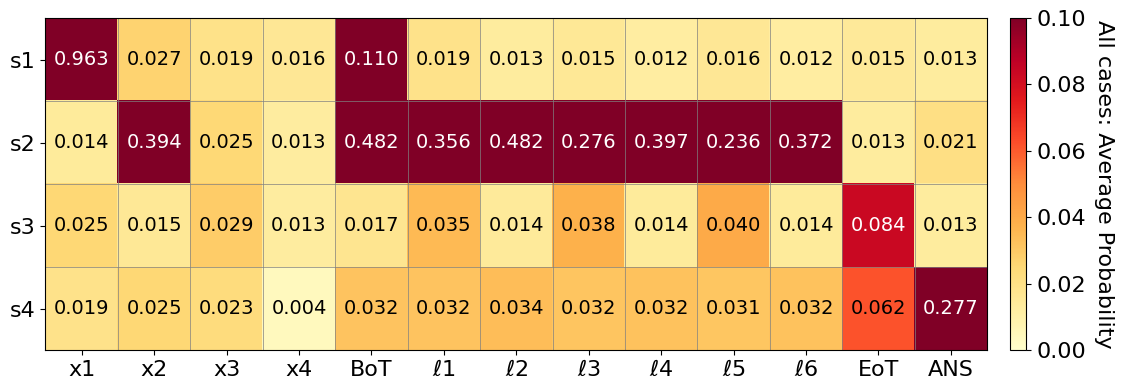

In [166]:
fig_s, ax_s, df_s = plot_prob_heatmap(
    latent_results_s_all, 
    len(sequence_tokens_all), 
    token_prefix='s', 
    title_suffix='(COMPUTATION TOKENS)',
    position_order=position_order, 
    save_figure=True,
    seq_len=seq_len,
    plot_type='All',
    fontsize_offset=2,
)
plt.show()

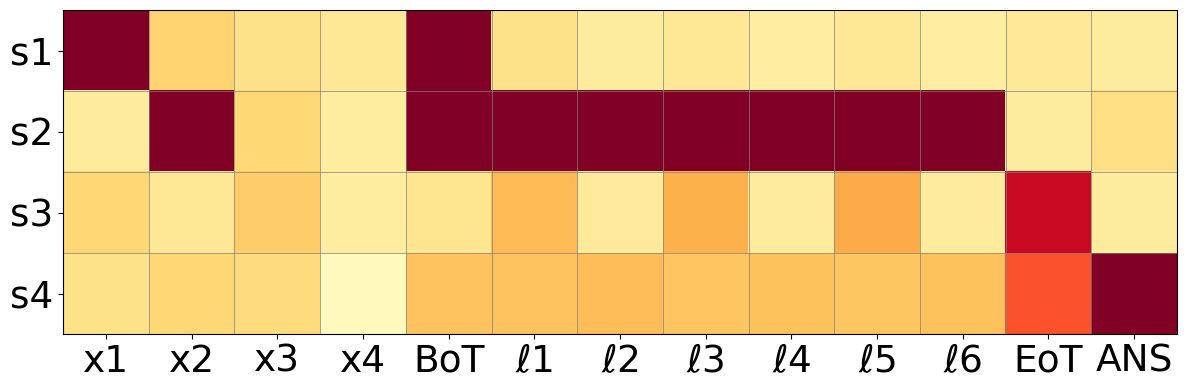

In [167]:
fig_s, ax_s, df_s = plot_prob_heatmap(
    latent_results_s_all, 
    len(sequence_tokens_all), 
    token_prefix='s', 
    title_suffix='(COMPUTATION TOKENS)',
    position_order=position_order, 
    save_figure=True,
    seq_len=seq_len,
    plot_type='All_noText',
    fontsize_offset=13,
    if_colorbar=False,
    if_show_celltext=False,
)
plt.show()